# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_TREND_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market_ma']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-13 14:35:11.208 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/13 14:35:11 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/13 14:35:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-6272489a-1034-4a23-9bfe-76b4fc7786c6;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 68ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/13 14:35:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/13 14:35:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/13 14:35:13 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/13 14:35:13 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/13 14:35:13 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
2026-03-13 14:35:14.238 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (683596, 131)
Years: 1985


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week
count,683596,683596.000000,6.835960e+05,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,...,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000
mean,2010-09-19 10:36:10.166005248,67.957243,7.811341e+06,0.000429,0.000088,-0.004572,-0.003598,-0.002588,-0.000276,0.000098,...,1.901064e+00,-9.804045e+09,7.328922e+08,5.671369e+09,-2.641322e+10,0.780337,0.219663,2010.214094,6.561390,3.963651
min,1985-09-06 00:00:00,0.004101,1.000000e+01,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-6.085191e+05,-9.736720e+11,-2.851201e+13,-2.657730e+11,-3.100327e+12,0.000000,0.000000,1985.000000,1.000000,0.000000
25%,2003-02-21 00:00:00,12.120000,9.523140e+05,-0.004305,0.000004,-0.504065,-0.502890,-0.502538,-0.499044,-0.498998,...,3.502875e+00,-7.154000e+09,-6.622557e+06,0.000000e+00,-1.340080e+10,1.000000,0.000000,2003.000000,4.000000,4.000000
50%,2012-07-13 00:00:00,29.180000,2.186242e+06,0.000874,0.000063,-0.004739,-0.003690,0.000000,0.000000,0.000000,...,4.366362e+01,-2.026300e+09,1.245994e+08,1.641900e+09,-3.365100e+09,1.000000,0.000000,2012.000000,7.000000,4.000000
75%,2019-09-13 00:00:00,67.410000,5.093956e+06,0.005707,0.000174,0.493976,0.495702,0.497099,0.498182,0.499044,...,9.445779e+01,-1.070000e+08,5.624792e+08,6.045000e+09,-8.793100e+07,1.000000,0.000000,2019.000000,10.000000,4.000000
max,2026-02-20 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.646007e+06,4.842830e+11,2.853340e+13,1.622538e+12,3.164338e+13,1.000000,1.000000,2026.000000,12.000000,4.000000
std,NaN,192.396685,4.653942e+07,0.010902,0.000087,0.577229,0.577935,0.577449,0.577008,0.577260,...,1.666346e+04,4.049973e+10,3.152945e+11,2.513286e+10,3.384185e+11,0.414019,0.414019,10.692233,3.463922,0.206899


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
import pandas as pd
import numpy as np

def create_advanced_target(df, forward_weeks=4):
    """
    Calculates a rolling forward return on weekly data, then converts it 
    into a Cross-Sectional Z-Score to isolate 'Alpha' from 'Beta'.
    """
    df = df.copy()
    
    # 0. S'assurer des formats et du tri initial (CRITIQUE pour le shift)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # 1. Calculer le rendement futur sur N semaines (ex: 4 semaines = 1 mois)
    # On divise le prix dans 4 semaines par le prix d'aujourd'hui
    df['target_y'] = df.groupby('symbol')['adjClose'].shift(-forward_weeks) / df['adjClose'] - 1
    
    # 5. Nettoyer le dataset final
    df = df.dropna(subset=['target_y'])
    
    return df

df = create_advanced_target(df, forward_weeks=52)


## 4. Algorithm Model Architectures

In [5]:

Valorisation = ['priceToBookRatio', 'priceToSalesRatio', 'priceToEarningsRatio', 'evToEBITDA', 'freeCashFlowYield']
Profitable = ['returnOnEquity', 'returnOnInvestedCapital', 'returnOnAssets', 'grossProfitMargin', 'operatingProfitMargin', 'ebitdaMargin']
Momentum = ['market_return', 'risk_free_rate', 'retvol', 'maxret', 'ill', 'beta', 'mom1w', 'mom1m', 'mom3m', 'mom6m', 'mom12m', 'mom36m', 'mom60m', 'chmom', 'high52', 'dist_ma4', 'dist_ma12', 'dist_ma25', 'dist_ma50']
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'target_y']

features = set(Valorisation) | set(Profitable) | set(Momentum) - set(colonnes_biais)
features = list(features)
print("features :", features)

features : ['high52', 'mom12m', 'mom1w', 'priceToBookRatio', 'operatingProfitMargin', 'maxret', 'priceToEarningsRatio', 'mom3m', 'market_return', 'mom36m', 'chmom', 'risk_free_rate', 'ebitdaMargin', 'dist_ma4', 'dist_ma50', 'mom60m', 'grossProfitMargin', 'priceToSalesRatio', 'beta', 'freeCashFlowYield', 'returnOnAssets', 'mom6m', 'retvol', 'ill', 'dist_ma12', 'evToEBITDA', 'returnOnEquity', 'dist_ma25', 'returnOnInvestedCapital', 'mom1m']


In [6]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol           0
date             0
adjClose         0
volume           0
market_return    0
                ..
bear_market      0
year             0
month            0
week             0
target_y         0
Length: 132, dtype: int64
Data after target creation: (646208, 132)
Years: 1985


## 2. Expanding Window Time-Series Split

In [7]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=6)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")


Total years in dataset: 1985 to 2025
Train ends before: 2015
Validation: 2015 to 2019
Test: 2020 to 2025

Total static splits: 1
Split 1 | Test Period: 2020 | Train: 392556 rows | Val: 120941 rows | Test: 132711 rows


In [8]:
"""
def get_train_val_test_splits(df, initial_train_years=50, val_years=3, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=50, val_years=3, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr) in enumerate(splits):\n    pri

## Reduction Features

Features à supprimer (corrélation > 0.8) :
{'ebitdaMargin', 'dist_ma50', 'priceToSalesRatio', 'mom6m', 'returnOnEquity', 'dist_ma25', 'returnOnInvestedCapital', 'mom1m'}


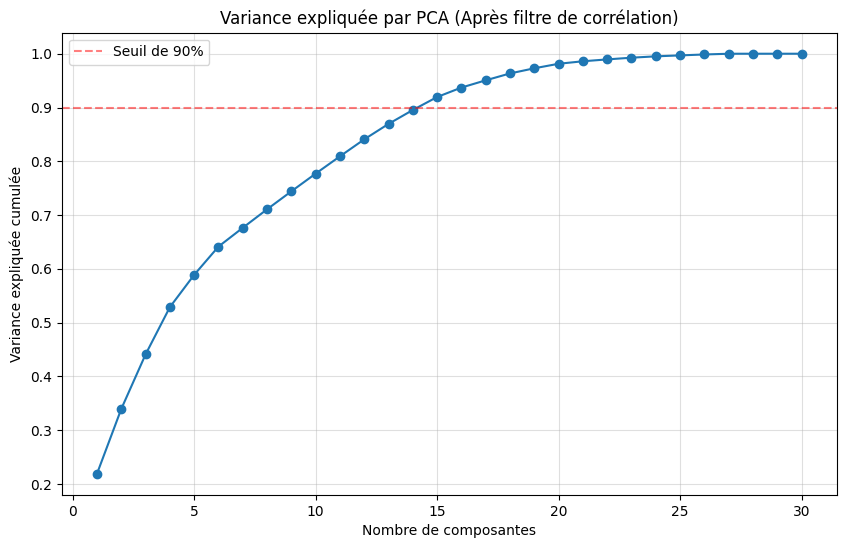

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train (en format DataFrame)
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()  # Ensemble des colonnes à supprimer
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features à supprimer (corrélation > {threshold}) :")
    print(col_corr)

    # DataFrame réduit
    #df_reduced = X_train_df.drop(columns=col_corr)
    #print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA (Sur le DataFrame réduit !)
    # ---------------------------------------------------------
    # Centrage et Réduction
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df) 
    
    # Entraînement de la PCA
    pca = PCA()
    pca.fit(X_train_scale)

    # Calcul de la variance expliquée
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage du graphique
    plt.figure(figsize=(10, 6))
    # range(1, ...) permet d'avoir l'axe X qui commence à 1 composante (et pas 0)
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%') # Ligne visuelle
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [10]:
def calculate_spearman_ic(y_true, y_pred):
    """
    Calculates the Spearman Rank Information Coefficient (IC).
    Measures how well the predicted rankings match the actual return rankings.
    Returns the correlation coefficient (IC).
    """
    # Flatten just in case they are passed as column vectors or pandas Series
    y_true_array = np.asarray(y_true).flatten()
    y_pred_array = np.asarray(y_pred).flatten()
    
    # Calculate Spearman Rank Correlation
    # nan_policy='omit' ensures that any missing data won't crash the calculation
    ic, p_value = spearmanr(y_pred_array, y_true_array, nan_policy='omit')
    
    # If the array is perfectly constant (e.g., model predicts the same value for all stocks), 
    # scipy returns NaN. We catch this and return 0.
    if np.isnan(ic):
        return 0.0
        
    return ic


### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import keras_tuner as kt
import mlflow

# ==========================================
# 1. CUSTOM PAIRWISE MARGIN LOSS
# ==========================================
def pairwise_margin_loss(margin=0.1):
    """
    If y_true = 1 (A beat B), we want (Score_A - Score_B) > margin
    If y_true = -1 (B beat A), we want (Score_A - Score_B) < -margin
    """
    def loss(y_true, y_pred):
        # y_pred is the output of the Subtract layer (Score_A - Score_B)
        # y_true is the actual label (+1 or -1)
        return tf.reduce_mean(tf.maximum(0.0, margin - y_true * y_pred))
    return loss

# ==========================================
# 2. FAST VECTORIZED PAIR GENERATOR
# ==========================================
def create_random_pairs(X, y, multiplier=2):
    """
    Generates random pairs of stocks to train the network on relative outperformance.
    multiplier=2 means it generates 2 * N pairs to ensure plenty of training data.
    """
    n = len(X)
    num_pairs = n * multiplier
    
    # Randomly select indices for Stock A and Stock B
    idx_A = np.random.randint(0, n, num_pairs)
    idx_B = np.random.randint(0, n, num_pairs)
    
    X_A = X[idx_A]
    X_B = X[idx_B]
    
    y_A = y.values[idx_A] if hasattr(y, 'values') else y[idx_A]
    y_B = y.values[idx_B] if hasattr(y, 'values') else y[idx_B]
    
    # Label is +1 if Stock A had a higher return than Stock B, else -1
    y_pair = np.where(y_A > y_B, 1.0, -1.0)
    
    return X_A, X_B, y_pair

# ==========================================
# 3. SIAMESE KerasTuner BUILDER
# ==========================================
def build_siamese_model(hp, input_dim):
    # --- A. The Core Scorer Network (Shared Weights) ---
    scorer = keras.Sequential(name="scorer_network")
    scorer.add(layers.Input(shape=(input_dim,)))
    
    # Added heavy Dropout as discussed to prevent overfitting noisy financial data
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    scorer.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    scorer.add(layers.BatchNormalization())
    scorer.add(layers.LeakyReLU(alpha=0.01)) # LeakyReLU prevents dead neurons during crashes
    scorer.add(layers.Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1))) 
    
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    scorer.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    scorer.add(layers.BatchNormalization())
    scorer.add(layers.LeakyReLU(alpha=0.01))
    scorer.add(layers.Dropout(hp.Float('dropout_2', 0.2, 0.4, step=0.1)))
    
    scorer.add(layers.Dense(1)) # Outputs the raw "Strength Score"
    
    # --- B. The Siamese Wrapper (For Training) ---
    input_A = layers.Input(shape=(input_dim,), name="input_A")
    input_B = layers.Input(shape=(input_dim,), name="input_B")
    
    # Both inputs pass through the EXACT SAME network
    score_A = scorer(input_A)
    score_B = scorer(input_B)
    
    # The output of the Siamese network is the difference between the two scores
    score_diff = layers.Subtract(name="score_diff")([score_A, score_B])
    
    siamese_model = keras.Model(inputs=[input_A, input_B], outputs=score_diff)
    
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    siamese_model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=hp_learning_rate, weight_decay=1e-4),
        loss=pairwise_margin_loss(margin=0.1) # Replaced MSE with Margin Loss
    )
    return siamese_model

# ==========================================
# 4. TRAINING & PREDICTION
# ==========================================
def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]
    
    # Generate Pairs for Training and Validation
    print("Generating structural momentum pairs...")
    X_train_A, X_train_B, y_train_pair = create_random_pairs(X_train_scaled, y_train, multiplier=2)
    X_val_A, X_val_B, y_val_pair = create_random_pairs(X_val_scaled, y_val, multiplier=1)
    
    batch_size = 32768 
    
    # tf.data pipeline now uses dictionaries mapping to the Input layer names
    train_dataset = tf.data.Dataset.from_tensor_slices((
        {"input_A": X_train_A, "input_B": X_train_B}, y_train_pair
    )).shuffle(buffer_size=len(X_train_A)).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
                                 
    val_dataset = tf.data.Dataset.from_tensor_slices((
        {"input_A": X_val_A, "input_B": X_val_B}, y_val_pair
    )).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

    print("Starting Siamese KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_siamese_model(hp, input_dim),
            objective='val_loss',
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='pairwise_momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"Pairwise_Ensemble_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            history = model.fit(train_dataset, epochs=epochs, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
            
            # --- THE CRITICAL EXTRACTION ---
            # We don't want to save the Siamese wrapper. We only want the internal scorer!
            scorer_network = model.get_layer("scorer_network")
            models.append(scorer_network) 
            
            print(f"Trained Siamese component {i+1}/{num_models} - Best Val Loss: {min(history.history['val_loss']):.6f}")
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    """
    During live prediction, we don't use pairs. We pass individual stocks through 
    the extracted 'scorer_network' to get their raw structural momentum rank.
    """
    X_test_scaled = scaler.transform(X_test)
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled).batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for scorer_model in models:
        # Just predict the raw strength score
        pred = scorer_model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Decile Sorting)

In [12]:
import pandas as pd
import numpy as np

def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    Invests strictly in the Top N performing stocks based on predictions_col.
    """
    results = []
    
    # CRITICAL FIX 1: Sort dataframe before shift(-1)
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calculate future return (what we will earn if we hold for the next period)
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # Initialize empty set to track what we held the previous week
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        # Skip weeks with too few stocks to form a proper Top N portfolio
        if len(week_data) < top_n: 
            continue
            
        week_data = week_data.copy()
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO TOP N (LONG ONLY) ---
        try:
            # 🚀 NOUVEAU : On trie les actions par la colonne de prédiction/performance
            # ascending=False permet d'avoir les plus grandes valeurs en haut
            week_data = week_data.sort_values(by=predictions_col, ascending=False)
            
            # On prend strictement le Top N
            long_portfolio = week_data.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # Gross Return (Equal-Weighted)
                ret_long = long_portfolio['return+1'].mean()
                gross_portfolio_return = ret_long 
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Turnover: Fraction of the portfolio that is new
                turnover_long = len(new_longs) / num_l if prev_long_symbols else 1.0 
                
                # Fee to BUY the new stock AND SELL the old stock
                cost_long = turnover_long * transaction_cost * 2
                
                # Net Return
                net_portfolio_return = gross_portfolio_return - cost_long
                
                # Update memory for the next loop
                prev_long_symbols = curr_long_symbols
            else:
                ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
                
        except Exception as e:
            ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
            
        # Append results for this week
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    # Cumulative returns
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    # Portfolio Metrics
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    # Benchmark Metrics
    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics

## 6. Run the Pipeline over the Expanding Window

In [ ]:
if len(splits) > 0:
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 year"
    NUM_SPLITS = 1
    TOP = 10
    NOTES = "Test avec une target de 1 year et une fréquence hebdomadaire avec 1 splits. Momentum et profitable"

    mlflow.set_experiment("Maximize_CAGR_SP500")
    
    run_name = f"Test_{STRATEGY_FREQ}_Cost{TRANS_COST}_DnnEp{DNN_EPOCHS}_DnnModels{DNN_MODELS}_Target{TARGET_FREQ}_Top{TOP}_Splits{NUM_SPLITS}_Notes{NOTES}"

    # On ouvre un seul grand Run MLflow pour tout le backtest
    with mlflow.start_run(run_name="CAGR_Forward_Backtest") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        
        # 1. ENREGISTREMENT DES PARAMÈTRES GLOBAUX
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "features_list": ", ".join(features),
            "transaction_cost": TRANS_COST,
            "dnn_epochs": DNN_EPOCHS,
            "dnn_num_models": DNN_MODELS,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # 2. LA BOUCLE SUR TOUTES LES ANNÉES
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            # Setup scaler for DNN (réajusté chaque année)
            scaler = StandardScaler()
            scaler.fit(X_train)
            
            # Entraînement DNN
            print("  -> Training DNN Ensemble...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            dnn_preds = predict_dnn_ensemble(dnn_models, scaler, X_test)
            
            # --- SUIVI ANNÉE PAR ANNÉE ---
            r2_dnn_year = float(calculate_spearman_ic(y_test.values, dnn_preds))
            
            # On force le cast en int() pour le step !
            mlflow.log_metric("Yearly_DNN_R2_OOS", r2_dnn_year, step=int(test_year))
            
            print(f"  -> DNN R2 {test_year}: {r2_dnn_year:.4f}")
            
            # Stockage des prédictions pour cette année
            test_df_year = df.loc[test_idx].copy()
            test_df_year['dnn_pred'] = dnn_preds
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 3. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul du Backtest Global...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        # --- SAUVEGARDE DES PRÉDICTIONS BRUTES EN ARTEFACT ---
        print("💾 Sauvegarde des prédictions brutes dans MLflow...")
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        # Évaluation R^2 globale sur toute la période OOS
        r2_dnn_global = calculate_spearman_ic(final_test_df['target_y'].values, final_test_df['dnn_pred'].values)
        
        mlflow.log_metric("Global_DNN_R2_OOS", r2_dnn_global)
        
        # Passage au simulateur de portefeuille
        print("Running Backtest for DNN Strategy...")
        bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=TRANS_COST, top_n=TOP)
        
        # 4. AFFICHAGE ET SAUVEGARDE FINALE
        if not bt_dnn.empty:
            
            # Sauvegarde des métriques financières dans MLflow en forçant le type float()
            mlflow.log_metrics({f"DNN_{k}": float(v) for k, v in metrics_dnn.items()})
            
            # Sauvegarde aussi le R2 global en forçant le float() (juste au cas où)
            mlflow.log_metric("Global_DNN_R2_OOS", float(r2_dnn_global))
            
            # Formatage du joli tableau pour la console
            metrics_table = pd.DataFrame({
                "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
                "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
            })
            
            print("\n" + "="*55)
            print("📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)")
            print("="*55)
            print(metrics_table.to_string(index=False))
            print("="*55 + "\n")
            
            # Sauvegarde du tableau en format texte brut dans MLflow
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
        else:
            print("Backtest yielded empty results (perhaps not enough data to form deciles).")
          
else:
    print("Not enough data to form a split. Check your timeframe.")


🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2020 (1/1) ---
  -> Training DNN Ensemble...
Generating structural momentum pairs...


2026-03-13 14:35:52.427216: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-13 14:35:52.427241: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-13 14:35:52.427249: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1773408952.427260  139099 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773408952.427280  139099 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Starting Siamese KerasTuner RandomSearch...


2026-03-13 14:36:38.390603: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026/03/13 14:36:38 WARNING mlflow.data.tensorflow_dataset: Failed to infer schema for TensorFlow dataset. Exception: Failed to infer schema for tf.data.Dataset. Schemas can only be inferred if the dataset consists of tensors. Ragged tensors, tensor arrays, and other types are not supported. Additionally, datasets with nested tensors are not supported.
2026-03-13 14:36:38.415204: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026/03/13 14:36:38 WARNING mlflow.data.tensorflow_dataset: Failed to infer schema for TensorFlow dataset. Exception: Failed to infer schema for tf.data.Dataset. Schemas can only be inferred if the dataset consists of tensors. Ragged tensors, tensor arrays, and other types are not supported. Additionally, datasets with nested tensors are

2026-03-13 14:36:38.727915: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

2026/03/13 14:37:32 WARNING mlflow.data.tensorflow_dataset: Failed to infer schema for TensorFlow dataset. Exception: Failed to infer schema for tf.data.Dataset. Schemas can only be inferred if the dataset consists of tensors. Ragged tensors, tensor arrays, and other types are not supported. Additionally, datasets with nested tensors are not supported.
2026/03/13 14:37:32 WARNING mlflow.data.tensorflow_dataset: Failed to infer schema for TensorFlow dataset. Exception: Failed to infer schema for tf.data.Dataset. Schemas can only be inferred if the dataset consists of tensors. Ragged tensors, tensor arrays, and other types are not supported. Additionally, datasets with nested tensors are not supported.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


2026/03/13 14:37:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 14:37:41 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/tmpid9w5cf6/model, flavor: tensorflow). Fall back to return ['tensorflow==2.18.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/03/13 14:37:41 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.09702794998884201 is not in list


Trained Siamese component 5/5 - Best Val Loss: 0.112983


  -> DNN R2 2020: 0.0685

🔗 Assemblage des prédictions et calcul du Backtest Global...
💾 Sauvegarde des prédictions brutes dans MLflow...
Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)
        Métrique DNN Ensemble
    Total Return       65.72%
CAGR (Annualisé)        8.78%
    Sharpe Ratio         0.46
    Max Drawdown      -46.13%



## 7. Visualisation results

Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)
        Métrique DNN Ensemble
    Total Return       71.85%
CAGR (Annualisé)        9.44%
    Sharpe Ratio         0.47
    Max Drawdown      -43.44%



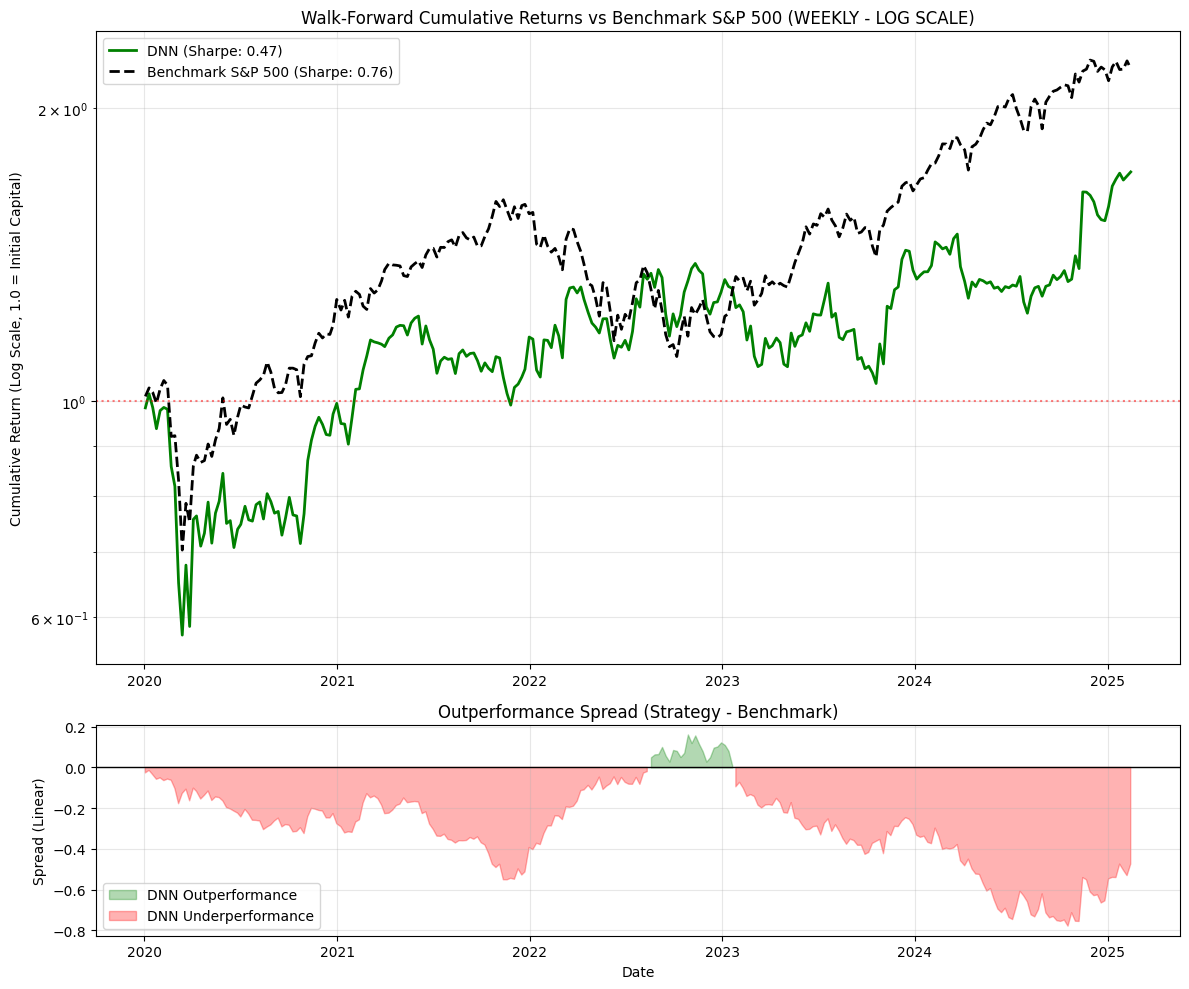

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running Backtest for DNN Strategy...")
# On garde ton paramétrage (transaction_cost=0.001, decile=55)
bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=0.001, top_n=5)

if not bt_dnn.empty:
    # 1. TABLEAU DES PERFORMANCES (DNN UNIQUEMENT)
    metrics_table = pd.DataFrame({
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
        "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
    })
    
    print("\n" + "="*55)
    print("📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)")
    print("="*55)
    print(metrics_table.to_string(index=False))
    print("="*55 + "\n")

    # 2. GRAPHIQUES (DNN vs BENCHMARK)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    # --- Axe 1 : Rendements cumulés (Échelle Logarithmique) ---
    ax1.plot(bt_dnn['date'], bt_dnn['cum_return'], label=f"DNN (Sharpe: {metrics_dnn['Sharpe_Ratio']:.2f})", color='green', linewidth=2)
    
    # On utilise maintenant metrics_dnn pour récupérer le Sharpe du Benchmark
    ax1.plot(bt_dnn['date'], bt_dnn['cum_benchmark'], label=f"Benchmark S&P 500 (Sharpe: {metrics_dnn['Bench_Sharpe']:.2f})", color='black', linestyle='--', linewidth=2)
    
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward Cumulative Returns vs Benchmark S&P 500 (WEEKLY - LOG SCALE)')
    ax1.set_ylabel('Cumulative Return (Log Scale, 1.0 = Initial Capital)')
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.3)
    
    # --- Axe 2 : Spread d'Outperformance (DNN uniquement) ---
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] >= 0), color='green', alpha=0.3, label='DNN Outperformance')
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] < 0), color='red', alpha=0.3, label='DNN Underperformance')
    
    ax2.axhline(y=0.0, color='black', linewidth=1)
    ax2.set_title('Outperformance Spread (Strategy - Benchmark)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spread (Linear)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()

    # 3. SAUVEGARDE MLFLOW
    plot_path = "global_cumulative_returns_vs_benchmark.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    
    plt.show()
    
else:
    print("Le backtest du DNN est vide (peut-être pas assez de données pour former les déciles).")

In [15]:
final_test_df.sort_values(by=['date', 'dnn_pred'], ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred
306983,IFF,2025-02-21,78.07,1571215,-0.017064,0.000171,0.672381,-0.280000,0.657143,-0.885714,...,1.609600e+09,-1.614000e+09,-6.763000e+09,1,0,2025,2,4,0.042526,0.040083
575301,TRMB,2025-02-21,71.47,1852437,-0.017064,0.000171,0.466667,-0.173333,0.786667,0.512381,...,-9.133538e+06,-2.412000e+08,-1.472600e+09,1,0,2025,2,4,-0.053869,0.036947
606012,VNO,2025-02-21,37.94,1113600,-0.017064,0.000171,-0.219048,-0.980952,0.961905,-0.238095,...,2.411968e+08,6.053654e+09,-8.111247e+09,1,0,2025,2,4,-0.233790,0.034822
113754,CCL,2025-02-21,23.11,31226448,-0.017064,0.000171,0.813333,0.005714,0.169524,0.809524,...,3.925225e+08,7.509000e+09,-3.642800e+10,1,0,2025,2,4,0.384249,0.032362
181105,DOC,2025-02-21,18.54,5557934,-0.017064,0.000171,-0.561905,0.028571,0.344762,-0.615238,...,-7.197979e+08,8.240370e+09,-9.894486e+09,1,0,2025,2,4,-0.083603,0.030368
192154,DXC,2025-02-21,19.56,871300,-0.017064,0.000171,0.893333,0.897143,0.988571,0.447619,...,-2.925954e+07,9.480000e+08,-4.706000e+09,1,0,2025,2,4,-0.317485,0.029289
210397,EPAM,2025-02-21,208.84,1694803,-0.017064,0.000171,0.958095,-0.977143,0.878095,0.874286,...,9.436070e+08,2.013158e+09,1.306926e+09,1,0,2025,2,4,-0.335137,0.026262
101138,C,2025-02-21,77.63,14907800,-0.017064,0.000171,-0.040000,-0.874286,-0.702857,-0.009524,...,-1.329900e+10,1.855720e+11,-1.594444e+12,1,0,2025,2,4,0.494268,0.024723
608135,VST,2025-02-21,149.63,9974300,-0.017064,0.000171,0.878095,-0.321905,-0.409524,0.961905,...,2.387082e+09,5.630000e+08,-2.406800e+10,1,0,2025,2,4,0.145492,0.024706
212771,EQT,2025-02-21,49.66,13804200,-0.017064,0.000171,0.706667,-0.314286,-0.074286,0.824762,...,3.099205e+08,2.198340e+10,-1.383744e+10,1,0,2025,2,4,0.218284,0.024541


In [16]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='dnn_pred', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred
639880,XOM,2023-01-06,99.05,16348131,0.022841,0.000185,0.363107,-0.479612,-0.906796,-0.782524,...,9.125423e+09,2.024730e+11,-6.896300e+10,0,1,2023,1,4,-0.039879,0.017100
497505,PXD,2023-01-06,216.48,1817165,0.022841,0.000185,0.568932,-0.087379,-0.328155,-0.223301,...,1.339506e+09,2.229800e+10,-9.473000e+09,0,1,2023,1,4,0.051275,0.016269
458326,OXY,2023-01-06,60.65,9832734,0.022841,0.000185,0.366990,-0.359223,-0.700971,-0.475728,...,2.264758e+09,3.008500e+10,-3.363800e+10,0,1,2023,1,4,-0.064303,0.015249
86128,BIIB,2023-01-06,279.25,3729267,0.022841,0.000185,-0.087379,-0.056311,-0.712621,-0.184466,...,-5.951413e+07,5.789300e+09,-1.374500e+09,0,1,2023,1,4,-0.076526,0.015074
495382,PTC,2023-01-06,122.69,524761,0.022841,0.000185,-0.180583,-0.487379,0.700971,0.137864,...,4.578633e+07,-3.618770e+08,-1.268426e+09,0,1,2023,1,4,0.351781,0.014527
464930,PCG,2023-01-06,15.79,10362316,0.022841,0.000185,0.308738,-0.794175,-0.040777,0.269903,...,-9.483021e+08,2.307500e+10,-8.275400e+10,0,1,2023,1,4,0.126662,0.014483
105702,CARR,2023-01-06,41.36,2726800,0.022841,0.000185,0.067961,0.572816,0.300971,0.417476,...,1.763952e+08,-3.243000e+09,-8.131000e+09,0,1,2023,1,4,0.312137,0.014349
275920,HAL,2023-01-06,37.56,8136800,0.022841,0.000185,0.751456,0.238835,0.048544,0.277670,...,4.794050e+08,5.148000e+09,-4.326000e+09,0,1,2023,1,4,-0.089191,0.014337
220158,EVRG,2023-01-06,56.95,1646450,0.022841,0.000185,-0.145631,-0.025243,0.464078,0.266019,...,-4.587312e+08,7.156700e+09,-1.815460e+10,0,1,2023,1,4,-0.133450,0.013089
210119,EOG,2023-01-06,113.22,2595724,0.022841,0.000185,0.487379,-0.328155,-0.413592,0.149515,...,1.319450e+09,2.477900e+10,-6.117000e+09,0,1,2023,1,4,-0.010775,0.012807


In [17]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred
444448,NVDA,2023-01-06,14.84,405044000,0.022841,0.000185,0.817476,0.654369,-0.980583,0.910680,...,4.105104e+09,1.512700e+10,4.084000e+09,0,1,2023,1,4,2.306604,0.004997
392880,META,2023-01-06,129.12,27584500,0.022841,0.000185,-0.324272,0.483495,-0.976699,-0.623301,...,1.280177e+09,1.045100e+11,-4.650000e+08,0,1,2023,1,4,1.706784,-0.018435
502101,RCL,2023-01-06,54.04,3117928,0.022841,0.000185,0.895146,0.972816,0.456311,0.196117,...,-1.463746e+09,2.060000e+09,-2.770200e+10,0,1,2023,1,4,1.230385,-0.017019
37358,AMD,2023-01-06,63.96,70161340,0.022841,0.000185,0.522330,-0.234951,-0.968932,0.755340,...,2.184737e+08,6.455000e+09,2.189000e+09,0,1,2023,1,4,1.166667,-0.057593
481532,PHM,2023-01-06,47.18,1952734,0.022841,0.000185,-0.883495,-0.231068,0.401942,-0.786408,...,-8.827305e+08,8.778293e+09,7.500014e+09,0,1,2023,1,4,1.119330,-0.009398
579354,TSLA,2023-01-06,113.06,220911100,0.022841,0.000185,0.992233,0.817476,-0.992233,0.992233,...,3.971328e+07,4.530500e+10,4.477000e+09,0,1,2023,1,4,1.100566,-0.043246
44323,ANET,2023-01-06,28.11,9314232,0.022841,0.000185,0.848544,-0.130097,-0.118447,0.440777,...,-6.117004e+07,4.497691e+09,3.661158e+09,0,1,2023,1,4,1.053718,0.002577
381749,MBC,2023-01-06,7.55,3381260,0.022841,0.000185,0.693204,-0.366990,0.972816,0.697087,...,1.580000e+08,-2.648000e+08,-6.902000e+08,0,1,2023,1,4,0.884768,-0.004494
113643,CCL,2023-01-06,9.16,40099578,0.022841,0.000185,0.933981,0.984466,0.064078,-0.099029,...,-3.173839e+09,5.329000e+09,-3.714700e+10,0,1,2023,1,4,0.883188,-0.025304
435528,NOW,2023-01-06,73.31,13383640,0.022841,0.000185,0.883495,-0.499029,-0.549515,0.766990,...,5.047377e+08,3.976000e+09,-1.613000e+09,0,1,2023,1,4,0.844632,-0.009772


In [18]:
df_test_decile = final_test_df.copy()

In [19]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred,decile
count,132711,132711.000000,1.327110e+05,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,...,1.327110e+05,1.327110e+05,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000,132711.000000
mean,2022-08-02 06:44:17.051789056,154.966614,6.451465e+06,0.000778,0.000105,-0.009275,-0.005686,-0.016336,-0.001531,0.002227,...,6.930559e+09,-4.440095e+10,0.770449,0.229551,2022.093240,6.428126,3.966695,0.155955,-0.002004,32.999985
min,2020-01-03 00:00:00,0.700230,6.000000e+02,-0.043360,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.146460e+11,-2.878834e+12,0.000000,0.000000,2020.000000,1.000000,3.000000,-0.997684,-3.175819,1.000000
25%,2021-04-16 00:00:00,47.580000,1.013107e+06,-0.005674,0.000004,-0.505837,-0.502913,-0.508571,-0.498054,-0.495146,...,-2.533000e+09,-2.529400e+10,1.000000,0.000000,2021.000000,3.000000,4.000000,-0.076616,-0.008789,17.000000
50%,2022-08-05 00:00:00,91.320000,2.144825e+06,0.001015,0.000099,-0.011765,-0.007782,-0.020952,-0.001949,0.003876,...,1.486196e+09,-8.266300e+09,1.000000,0.000000,2022.000000,6.000000,4.000000,0.106391,0.000100,33.000000
75%,2023-11-17 00:00:00,173.870000,5.024822e+06,0.007670,0.000209,0.484375,0.490196,0.473684,0.495146,0.499037,...,8.359000e+09,-2.338355e+09,1.000000,0.000000,2023.000000,9.000000,4.000000,0.319255,0.008469,49.000000
max,2025-02-21 00:00:00,9924.400000,1.463684e+09,0.092871,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.320010e+11,8.127400e+10,1.000000,1.000000,2025.000000,12.000000,4.000000,5.541555,0.091598,65.000000
std,NaN,327.500322,2.533690e+07,0.012747,0.000094,0.573646,0.574618,0.570625,0.574886,0.575281,...,3.561149e+10,1.838847e+11,0.420546,0.420546,1.486463,3.514593,0.179434,0.372568,0.061623,18.761871


In [20]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.302154750244858

In [21]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.638099902056807

In [22]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred,decile
306983,IFF,2025-02-21,78.07,1571215,-0.017064,0.000171,0.672381,-0.280000,0.657143,-0.885714,...,-1.614000e+09,-6.763000e+09,1,0,2025,2,4,0.042526,0.040083,65
575301,TRMB,2025-02-21,71.47,1852437,-0.017064,0.000171,0.466667,-0.173333,0.786667,0.512381,...,-2.412000e+08,-1.472600e+09,1,0,2025,2,4,-0.053869,0.036947,65
606012,VNO,2025-02-21,37.94,1113600,-0.017064,0.000171,-0.219048,-0.980952,0.961905,-0.238095,...,6.053654e+09,-8.111247e+09,1,0,2025,2,4,-0.233790,0.034822,65
261650,GNRC,2025-01-24,157.43,739431,-0.002855,0.000173,0.680000,0.070476,0.866667,-0.592381,...,3.026600e+08,-5.797180e+08,1,0,2025,1,4,0.098965,0.040902,65
606006,VNO,2025-01-10,36.93,1665500,-0.015415,0.000173,0.440000,-0.988571,0.961905,0.550476,...,6.053654e+09,-8.111247e+09,1,0,2025,1,4,-0.065529,0.039536,65
129085,CMA,2024-12-27,59.16,816018,-0.011052,0.000171,0.508571,0.287619,0.832381,0.748571,...,6.725000e+09,-6.380100e+10,1,0,2024,12,4,0.502874,0.034934,65
167070,DAY,2024-12-27,73.72,835905,-0.011052,0.000171,-0.348571,-0.881905,0.645714,-0.714286,...,-6.680000e+07,-6.571000e+08,1,0,2024,12,4,-0.061856,0.040874,65
337674,KEY,2024-09-06,14.83,12443300,-0.017260,0.000204,-0.426386,-0.980880,0.552581,0.108987,...,1.199600e+10,-1.459680e+11,1,0,2024,9,4,0.263655,0.045812,65
237960,FIS,2024-09-06,78.87,2725138,-0.017260,0.000204,-0.686424,-0.296367,-0.518164,-0.288719,...,-3.624000e+09,-1.110600e+10,1,0,2024,9,4,-0.138836,0.036988,65
261630,GNRC,2024-09-06,139.61,652783,-0.017260,0.000204,0.812620,-0.598470,0.934990,0.892925,...,1.405250e+08,-6.903890e+08,1,0,2024,9,4,0.298618,0.034078,65


26/03/13 20:00:28 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE